In [14]:
import warnings
from tensorflow.keras.utils import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import numpy as np
import re
import nltk
# nltk.download('all')
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('wordnet')
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
lemm = WordNetLemmatizer()

warnings.filterwarnings("ignore")

[nltk_data] Downloading package stopwords to /home/soheil/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /home/soheil/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /home/soheil/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to /home/soheil/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [15]:
# Loading the Dataset

data = pd.read_csv("Clothing-Review.csv")
data.head(7)

data = data[data['Class Name'].isnull() == False]

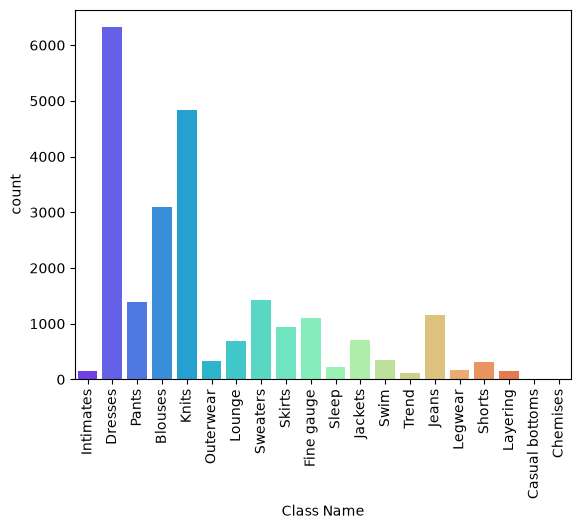

In [16]:
# Performing Exploratory Data Analysis

# Count Plot of Class Name Distribution
sns.countplot(data=data, x='Class Name', palette='rainbow')
plt.xticks(rotation=90)
plt.show()

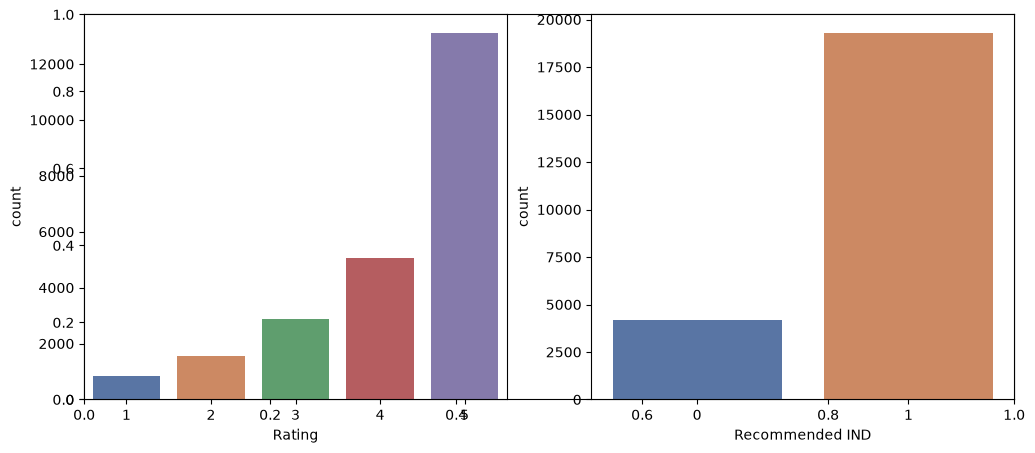

In [17]:
# Count Plot of Rating and Recommendation Distribution

plt.subplots(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.countplot(data=data, x='Rating',palette="deep")

plt.subplot(1, 2, 2)
sns.countplot(data=data, x="Recommended IND", palette="deep")
plt.show()

In [19]:
# Histogram of Age Distribution

fig = px.histogram(data, marginal='box',
                   x="Age", title="Age Group",
                   color="Recommended IND",
                   nbins=65-18,
                   color_discrete_sequence=['green', 'red'])
fig.update_layout(bargap=0.2)

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

Figure({
    'data': [{'bingroup': 'x',
              'hovertemplate': 'Recommended IND=1<br>Age=%{x}<br>count=%{y}<extra></extra>',
              'legendgroup': '1',
              'marker': {'color': 'green', 'pattern': {'shape': ''}},
              'name': '1',
              'nbinsx': 47,
              'orientation': 'v',
              'showlegend': True,
              'type': 'histogram',
              'x': {'bdata': ('ISIyLycnGCInNSwyLyIpIC8hNyI3Hz' ... 'EqKSI8IzInHyAdICkbJyojIjAcNA=='),
                    'dtype': 'i1'},
              'xaxis': 'x',
              'yaxis': 'y'},
             {'hovertemplate': 'Recommended IND=1<br>Age=%{x}<extra></extra>',
              'legendgroup': '1',
              'marker': {'color': 'green'},
              'name': '1',
              'notched': True,
              'showlegend': False,
              'type': 'box',
              'x': {'bdata': ('ISIyLycnGCInNSwyLyIpIC8hNyI3Hz' ... 'EqKSI8IzInHyAdICkbJyojIjAcNA=='),
                    'dtype': 'i1'},
              'xaxis': 'x2',
              'yaxis': 'y2'},
             {'bingroup': 'x',
              'hovertemplate': 'Recommended IND=0<br>Age=%{x}<br>count=%{y}<extra></extra>',
              'legendgroup': '0',
              'marker': {'color': 'red', 'pattern': {'shape': ''}},
              'name': '0',
              'nbinsx': 47,
              'orientation': 'v',
              'showlegend': True,
              'type': 'histogram',
              'x': {'bdata': ('PDE1Hx8hJCEfJCU4JBw6JiwsIRczLC' ... '4+GzkiOC8mLS9EIToqNTscJygiIB8='),
                    'dtype': 'i1'},
              'xaxis': 'x',
              'yaxis': 'y'},
             {'hovertemplate': 'Recommended IND=0<br>Age=%{x}<extra></extra>',
              'legendgroup': '0',
              'marker': {'color': 'red'},
              'name': '0',
              'notched': True,
              'showlegend': False,
              'type': 'box',
              'x': {'bdata': ('PDE1Hx8hJCEfJCU4JBw6JiwsIRczLC' ... '4+GzkiOC8mLS9EIToqNTscJygiIB8='),
                    'dtype': 'i1'},
              'xaxis': 'x2',
              'yaxis': 'y2'}],
    'layout': {'bargap': 0.2,
               'barmode': 'relative',
               'legend': {'title': {'text': 'Recommended IND'}, 'tracegroupgap': 0},
               'template': '...',
               'title': {'text': 'Age Group'},
               'xaxis': {'anchor': 'y', 'domain': [0.0, 1.0], 'title': {'text': 'Age'}},
               'xaxis2': {'anchor': 'y2', 'domain': [0.0, 1.0], 'matches': 'x', 'showgrid': True, 'showticklabels': False},
               'yaxis': {'anchor': 'x', 'domain': [0.0, 0.7326], 'title': {'text': 'count'}},
               'yaxis2': {'anchor': 'x2',
                          'domain': [0.7426, 1.0],
                          'matches': 'y2',
                          'showgrid': False,
                          'showline': False,
                          'showticklabels': False,
                          'ticks': ''}}
})

In [20]:
# Interpretation of Age Distribution Plot

fig = px.histogram(data,
                   x="Age",
                   marginal='box',
                   title="Age Group",
                   color="Rating",
                   nbins=65-18,
                   color_discrete_sequence
                   =['black', 'green', 'blue', 'red', 'yellow'])
fig.update_layout(bargap=0.2)

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

Figure({
    'data': [{'bingroup': 'x',
              'hovertemplate': 'Rating=4<br>Age=%{x}<br>count=%{y}<extra></extra>',
              'legendgroup': '4',
              'marker': {'color': 'black', 'pattern': {'shape': ''}},
              'name': '4',
              'nbinsx': 47,
              'orientation': 'v',
              'showlegend': True,
              'type': 'histogram',
              'x': {'bdata': ('IScvITcfQR0vQysuQiQ0OjwmLx8+Jy' ... 'MoHy4XGzU6GjUnJyM5MUEiMh8bJw=='),
                    'dtype': 'i1'},
              'xaxis': 'x',
              'yaxis': 'y'},
             {'hovertemplate': 'Rating=4<br>Age=%{x}<extra></extra>',
              'legendgroup': '4',
              'marker': {'color': 'black'},
              'name': '4',
              'notched': True,
              'showlegend': False,
              'type': 'box',
              'x': {'bdata': ('IScvITcfQR0vQysuQiQ0OjwmLx8+Jy' ... 'MoHy4XGzU6GjUnJyM5MUEiMh8bJw=='),
                    'dtype': 'i1'},
              'xaxis': 'x2',
              'yaxis': 'y2'},
             {'bingroup': 'x',
              'hovertemplate': 'Rating=5<br>Age=%{x}<br>count=%{y}<extra></extra>',
              'legendgroup': '5',
              'marker': {'color': 'green', 'pattern': {'shape': ''}},
              'name': '5',
              'nbinsx': 47,
              'orientation': 'v',
              'showlegend': True,
              'type': 'histogram',
              'x': {'bdata': ('IjIvJxgiJzUsKSAvNzUcIS4VJyYkOy' ... 'c+QSQnGiMxPyopPCMnIB0gKiMiNA=='),
                    'dtype': 'i1'},
              'xaxis': 'x',
              'yaxis': 'y'},
             {'hovertemplate': 'Rating=5<br>Age=%{x}<extra></extra>',
              'legendgroup': '5',
              'marker': {'color': 'green'},
              'name': '5',
              'notched': True,
              'showlegend': False,
              'type': 'box',
              'x': {'bdata': ('IjIvJxgiJzUsKSAvNzUcIS4VJyYkOy' ... 'c+QSQnGiMxPyopPCMnIB0gKiMiNA=='),
                    'dtype': 'i1'},
              'xaxis': 'x2',
              'yaxis': 'y2'},
             {'bingroup': 'x',
              'hovertemplate': 'Rating=3<br>Age=%{x}<br>count=%{y}<extra></extra>',
              'legendgroup': '3',
              'marker': {'color': 'blue', 'pattern': {'shape': ''}},
              'name': '3',
              'nbinsx': 47,
              'orientation': 'v',
              'showlegend': True,
              'type': 'histogram',
              'x': {'bdata': ('PDUyIiIfJx84JSEsMiInJyc1JCwrIy' ... 'A3KTM6Pj4UGiIpKDUcJygmIhgpMB8c'),
                    'dtype': 'i1'},
              'xaxis': 'x',
              'yaxis': 'y'},
             {'hovertemplate': 'Rating=3<br>Age=%{x}<extra></extra>',
              'legendgroup': '3',
              'marker': {'color': 'blue'},
              'name': '3',
              'notched': True,
              'showlegend': False,
              'type': 'box',
              'x': {'bdata': ('PDUyIiIfJx84JSEsMiInJyc1JCwrIy' ... 'A3KTM6Pj4UGiIpKDUcJygmIhgpMB8c'),
                    'dtype': 'i1'},
              'xaxis': 'x2',
              'yaxis': 'y2'},
             {'bingroup': 'x',
              'hovertemplate': 'Rating=2<br>Age=%{x}<br>count=%{y}<extra></extra>',
              'legendgroup': '2',
              'marker': {'color': 'red', 'pattern': {'shape': ''}},
              'name': '2',
              'nbinsx': 47,
              'orientation': 'v',
              'showlegend': True,
              'type': 'histogram',
              'x': {'bdata': ('MR8hJCElJBwmFzMgJSMhIzQuJSoqLi' ... 'AXOjg4HCsmLCU7LSgbJS8mLS86Kjs='),
                    'dtype': 'i1'},
              'xaxis': 'x',
              'yaxis': 'y'},
             {'hovertemplate': 'Rating=2<br>Age=%{x}<extra></extra>',
              'legendgroup': '2',
              'marker': {'color': 'red'},
              'name': '2',
              'notched': True,
              'showlegend': False,
              'type': 'box',
              'x': {'bdata': ('MR8hJCE

In [21]:
#  Prepare the Data to build Model

def filter_score(rating):
    return int(rating > 3)

features = ['Class Name', 'Title', 'Review Text']

X = data[features]
y = data['Rating']
y = y.apply(filter_score)

In [22]:
# Text Preprocessing

def toLower(data):
    if isinstance(data, float):
        return '<UNK>'
    else:
        return data.lower()

stop_words = stopwords.words("english")

def remove_stopwords(text):
    no_stop = []
    for word in text.split(' '):
        if word not in stop_words:
            no_stop.append(word)
    return " ".join(no_stop)

def remove_punctuation_func(text):
    return re.sub(r'[^a-zA-Z0-9]', ' ', text)

X['Title'] = X['Title'].apply(toLower)
X['Review Text'] = X['Review Text'].apply(toLower)

X['Title'] = X['Title'].apply(remove_stopwords)
X['Review Text'] = X['Review Text'].apply(remove_stopwords)

X['Title'] = X['Title'].apply(lambda x: lemm.lemmatize(x))
X['Review Text'] = X['Review Text'].apply(lambda x: lemm.lemmatize(x))

X['Title'] = X['Title'].apply(remove_punctuation_func)
X['Review Text'] = X['Review Text'].apply(remove_punctuation_func)

X['Text'] = list(X['Title']+X['Review Text']+X['Class Name'])


X_train, X_test, y_train, y_test = train_test_split(
    X['Text'], y, test_size=0.25, random_state=42)

In [23]:
#  Tokenization

tokenizer = Tokenizer(num_words=10000, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

In [24]:
# Padding the Text Data

train_seq = tokenizer.texts_to_sequences(X_train)
test_seq = tokenizer.texts_to_sequences(X_test)

train_pad = pad_sequences(train_seq,
                          maxlen=40,
                          truncating="post",
                          padding="post")
test_pad = pad_sequences(test_seq,
                         maxlen=40,
                         truncating="post",
                         padding="post")

In [26]:
# Building a Recurrent Neural Network (RNN) in TensorFlow

from tensorflow import keras

model = keras.models.Sequential()
model.add(keras.layers.Embedding(input_dim=10000, output_dim=128, input_length=40))
model.add(keras.layers.SimpleRNN(64, return_sequences=True))
model.add(keras.layers.SimpleRNN(64))
model.add(keras.layers.Dense(128, activation="relu"))
model.add(keras.layers.Dropout(0.4))
model.add(keras.layers.Dense(1, activation="sigmoid"))

model.build(input_shape=(None, 40))

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 40, 128)        │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_2 (SimpleRNN)        │ (None, 40, 64)         │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_3 (SimpleRNN)        │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,309,057 (4.99 MB)

 Trainable params: 1,309,057 (4.99 MB)

 Non-trainable params: 0 (0.00 B)

In [27]:
# Training the Model

model.compile(loss="binary_crossentropy",
              optimizer="adam",
              metrics=["accuracy"])
              

history = model.fit(train_pad,
                    y_train,
                    epochs=5)


Epoch 1/5
551/551 ━━━━━━━━━━━━━━━━━━━━ 15s 24ms/step - accuracy: 0.7722 - loss: 0.5260
Epoch 2/5
551/551 ━━━━━━━━━━━━━━━━━━━━ 13s 24ms/step - accuracy: 0.7763 - loss: 0.5177
Epoch 3/5
551/551 ━━━━━━━━━━━━━━━━━━━━ 11s 20ms/step - accuracy: 0.7791 - loss: 0.5138
Epoch 4/5
551/551 ━━━━━━━━━━━━━━━━━━━━ 13s 24ms/step - accuracy: 0.8035 - loss: 0.4677
Epoch 5/5
551/551 ━━━━━━━━━━━━━━━━━━━━ 13s 23ms/step - accuracy: 0.8399 - loss: 0.3811


In [29]:
# Evaluate the model on the test set
test_loss, test_accuracy = model.evaluate(
    test_pad,
    y_test,
    verbose=1
)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7125 - loss: 0.6230
Test Loss: 0.6230
Test Accuracy: 0.7125
Test Accuracy: 71.25%


In [28]:
# Make predictions
predictions = model.predict(test_pad)

# Convert probabilities to 0 or 1
predicted_classes = (predictions >= 0.5).astype(int).flatten()

# Show some predictions
for i in range(10):
    print(
        f"Actual: {y_test.iloc[i]} | "
        f"Predicted: {predicted_classes[i]} | "
        f"Probability: {predictions[i][0]:.4f}"
    )

184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step
Actual: 0 | Predicted: 0 | Probability: 0.4947
Actual: 1 | Predicted: 1 | Probability: 0.9635
Actual: 1 | Predicted: 0 | Probability: 0.4430
Actual: 1 | Predicted: 1 | Probability: 0.8603
Actual: 1 | Predicted: 1 | Probability: 0.9834
Actual: 1 | Predicted: 1 | Probability: 0.9979
Actual: 1 | Predicted: 1 | Probability: 0.9735
Actual: 1 | Predicted: 1 | Probability: 0.9344
Actual: 1 | Predicted: 1 | Probability: 0.7791
Actual: 0 | Predicted: 0 | Probability: 0.4356
